In [9]:
import numpy as np

import sys
sys.path.append(r"../Atomical")
from Properties import build_neighbor_array, find_rings_with_atoms_numba, ring_size_distribution, defect_atom_mask

data = np.load(r"../Crystals/T=10000K_k=1.npz")
xy = data["atoms"][:, :2] if "atoms" in data.files else data["xyz"][:, :2]
L = float(np.ravel(data["L"])[0]) if "L" in data.files else data["lattice"][0]

nb_sorted, deg = build_neighbor_array(xy, L, L)
ring_sizes, ring_atoms, n_excluded = find_rings_with_atoms_numba(nb_sorted, deg)

dist = ring_size_distribution(ring_sizes)
print(dist)   # ex: {5: 3.2, 6: 91.4, 7: 4.8, ...}

is_defect = defect_atom_mask(len(xy), ring_sizes, ring_atoms)
print(f"{100 * is_defect.sum() / len(xy):.1f}% des atomes sur un anneau non-hexagonal")

{3: np.float64(1.3586438956256746), 4: np.float64(0.29204494952701415), 5: np.float64(2.83156624976192), 6: np.float64(92.95917719509872), 7: np.float64(2.5522189067360803), 8: np.float64(0.0063488032505872646)}
12.8% des atomes sur un anneau non-hexagonal


bulk: 24998 atomes, GB: 6006 atomes


TypeError: 'Text' object is not callable

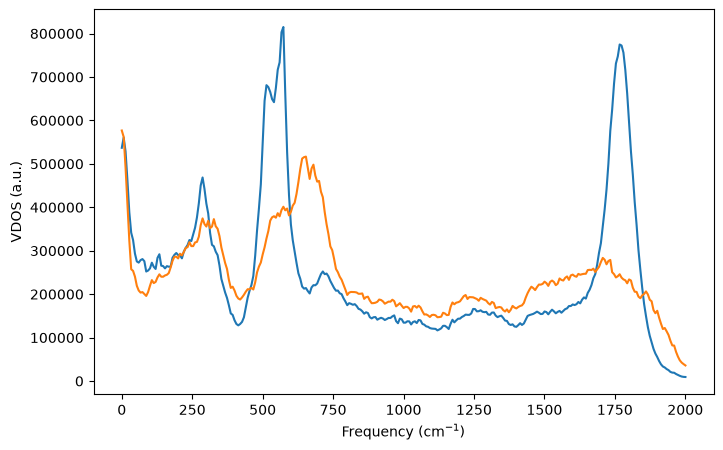

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from thermalize import ThermalizationResult, compute_vdos

# 1. Topologie sur le cristal brut (avant thermalisation)
raw = np.load("../Crystals/T=120000K_k=1.npz")
xy = raw["atoms"][:, :2] if "atoms" in raw.files else raw["xyz"][:, :2]
L = float(np.ravel(raw["L"])[0]) if "L" in raw.files else raw["lattice"][0]
T = int(raw.zip.filename.replace("\\", "/").rsplit("/", 1)[-1]
    .split("T=", 1)[1].split("K", 1)[0])

nb_sorted, deg = build_neighbor_array(xy, L, L)
ring_sizes, ring_atoms, _ = find_rings_with_atoms_numba(nb_sorted, deg)
is_defect = defect_atom_mask(len(xy), ring_sizes, ring_atoms)

bulk_idx = np.where(~is_defect)[0]   # TOUS les atomes bulk
gb_idx = np.where(is_defect)[0]      # TOUS les atomes GB
print(f"bulk: {len(bulk_idx)} atomes, GB: {len(gb_idx)} atomes")

# 2. VDOS moyenne par classe, sur le fichier thermalise correspondant
result = ThermalizationResult.load(rf"plots/T={T}_k=1_thermalized_300K.npz")
dt_frame_ps = result.times_ps[1] - result.times_ps[0]

freq_thz, vdos_bulk = compute_vdos(result.velocities[:, bulk_idx, :], dt_frame_ps=dt_frame_ps)
_, vdos_gb = compute_vdos(result.velocities[:, gb_idx, :], dt_frame_ps=dt_frame_ps)

mask = freq_thz <= 60.0
freq_cm1 = freq_thz[mask] * 33.356

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freq_cm1, vdos_bulk[mask] / len(bulk_idx), label=f"in grains ({len(bulk_idx)} atoms)")
ax.plot(freq_cm1, vdos_gb[mask] / len(gb_idx), label=f"gb ({len(gb_idx)} atoms)")
ax.set_xlabel("Frequency (cm$^{-1}$)")
ax.set_ylabel("VDOS (a.u.)")
ax.set_title(f"T={T}K")
ax.legend()
fig.savefig(rf"vdos_bulk_vs_gb_T={T}K.png", dpi=300)